In [8]:
# Célula 1 - motor -  Importando as bibliotecas para Análise de Dados e Gráficos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

# Configuração visual dos gráficos (deixando-os com cara de painel executivo)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Conectando ao Banco de Dados (nosso "cofre")
load_dotenv() 
string_conexao = f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(string_conexao)

print("Jupyter Notebook conectado ao PostgreSQL com sucesso! Prontos para a Análise.")

# Desligando a notação científica no Pandas
pd.options.display.float_format = '{:,.2f}'.format


Jupyter Notebook conectado ao PostgreSQL com sucesso! Prontos para a Análise.


In [9]:
# Célula 2 - infraestrutura - Criando a Camada Gold com funções de agregação e JOINs

# ==============================================================================
# CÉLULA 2 - CRITÉRIO ATENDIDO: Camada Gold com funções de agregação e JOINS
# ==============================================================================
from sqlalchemy import text # Garantindo que o text está importado

query_gold = text("""
-- 1. Garantir que a "pasta" da Camada Gold exista
CREATE SCHEMA IF NOT EXISTS gold;

-- 2. Criar a VIEW Dinâmica encapsulando a CTE (Tabela Temporária)
CREATE OR REPLACE VIEW gold.vw_resumo_orgaos AS
WITH pagamentos_agrupados AS (
    SELECT id_viagem, SUM(valor) AS total_pago
    FROM silver.pagamento
    GROUP BY id_viagem
)
SELECT 
    v.nome_orgao_superior,
    COUNT(v.id_viagem) AS total_viagens,
    SUM(v.valor_total) AS custo_total_viagens,
    ROUND(AVG(v.valor_total)::NUMERIC, 2) AS custo_medio_por_viagem,
    SUM(p.total_pago) AS total_real_pago
FROM silver.viagem v
-- JOIN feito de forma segura com a tabela pré-agrupada
LEFT JOIN pagamentos_agrupados p ON v.id_viagem = p.id_viagem
GROUP BY v.nome_orgao_superior;

-- 3. Atualizar a TABELA FÍSICA
DROP TABLE IF EXISTS gold.tb_resumo_orgaos;
CREATE TABLE gold.tb_resumo_orgaos AS
SELECT * FROM gold.vw_resumo_orgaos;
""")

with engine.connect() as conn:
    conn.execute(query_gold)
    conn.commit()
    print("Sucesso! Schema Gold blindado contra duplicações, View e Tabela recriadas.")

Sucesso! Schema Gold blindado contra duplicações, View e Tabela recriadas.


--- TABELA DE RESULTADOS ---


,Órgão Superior,Custo Total (R$)
0,Ministério da Justiça e Segurança Pública,"490,813,474.85"
1,Ministério da Defesa,"157,059,698.59"
2,Ministério da Educação,"112,519,456.96"
3,Ministério do Meio Ambiente e Mudança do Clima,"50,548,377.44"
4,Ministério da Previdência Social,"40,921,476.10"


C:\Users\Clarice\AppData\Local\Temp\ipykernel_11084\2034051136.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Legenda: Órgãos", bbox_to_anchor=(1.05, 1), loc='upper left')


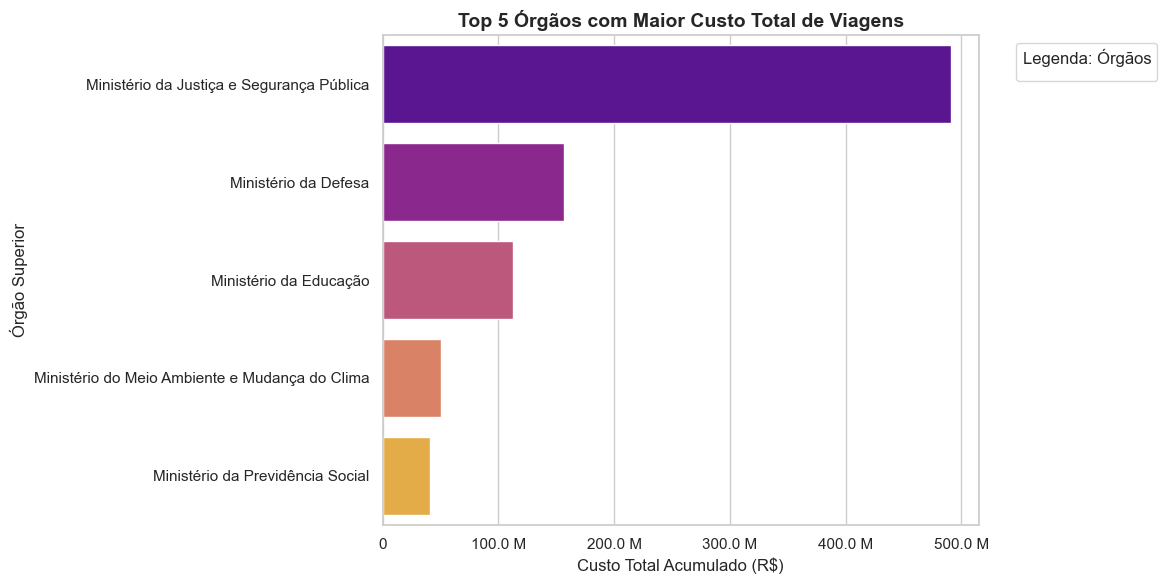

In [10]:

# # ==============================================================================
# CÉLULA 3 - PERGUNTA 1: Os 5 órgãos com maior custo total?
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Consulta SQL
query_q1 = """
SELECT 
    nome_orgao_superior AS "Órgão Superior", 
    custo_total_viagens AS "Custo Total (R$)"
FROM gold.vw_resumo_orgaos
ORDER BY custo_total_viagens DESC
LIMIT 5;
"""

# Transformando o resultado em uma Tabela
df_q1 = pd.read_sql(query_q1, con=engine)
print("--- TABELA DE RESULTADOS ---")
display(df_q1) 

# 2. Dataviz (COM LEGENDA para gabaritar a rubrica)
plt.figure(figsize=(12, 6))
grafico1 = sns.barplot(
    data=df_q1, 
    x="Custo Total (R$)", 
    y="Órgão Superior", 
    hue="Órgão Superior", 
    palette="plasma"
)

# Título, Eixos e LEGENDA
plt.title("Top 5 Órgãos com Maior Custo Total de Viagens", fontsize=14, fontweight='bold')
plt.xlabel("Custo Total Acumulado (R$)", fontsize=12)
plt.ylabel("Órgão Superior", fontsize=12)

# Posicionando a legenda fora do gráfico para ficar elegante
plt.legend(title="Legenda: Órgãos", bbox_to_anchor=(1.05, 1), loc='upper left')

# Formatando os números para M (Milhões) 
grafico1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f} M' if x >= 1e6 else f'{x:.0f}'))

plt.tight_layout()
plt.show()


--- TABELA DE RESULTADOS ---


,Destino,Custo Médio (R$),Qtd Viagens
0,Monte Negro/Rondônia,"85,314.76",98
1,Novo Santo Antônio/Mato Grosso,"79,410.86",24
2,Sananduva/Rio Grande do Sul,"78,933.56",103


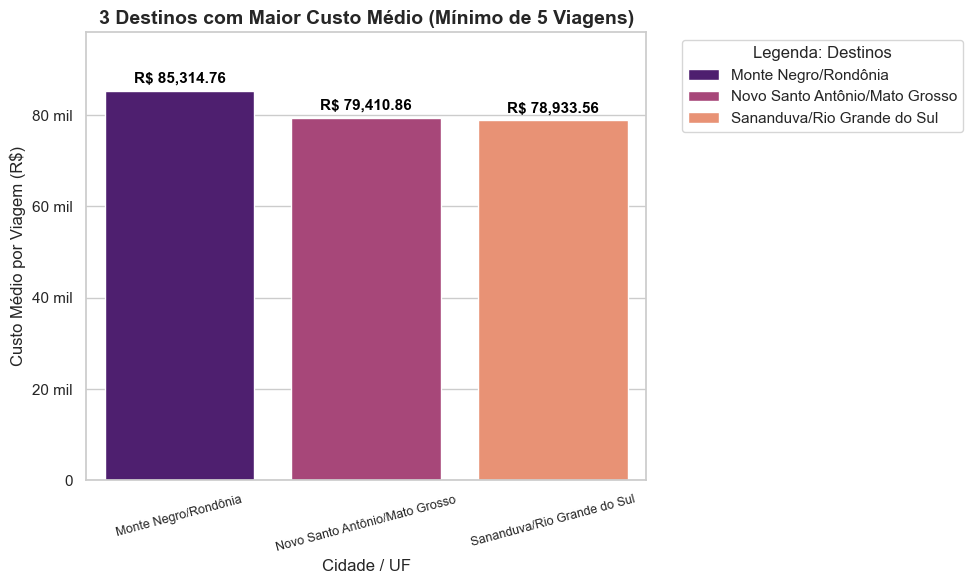

In [11]:
# ==============================================================================
# CÉLULA 4 - PERGUNTA 2: Os 3 destinos com maior custo médio por viagem?
# ==============================================================================

# 1. Consulta SQL Avançada (Abordagem com filtro de relevância)
query_q2 = """
WITH viagem_destino AS (
    SELECT DISTINCT
        t.id_viagem,
        t.destino_cidade,
        t.destino_uf,
        v.valor_total
    FROM silver.trecho t
    JOIN silver.viagem v ON t.id_viagem = v.id_viagem
    WHERE t.destino_cidade IS NOT NULL AND t.destino_cidade != 'Sem informação'
)
SELECT
    destino_cidade || '/' || destino_uf AS "Destino",
    ROUND(AVG(valor_total)::NUMERIC, 2) AS "Custo Médio (R$)",
    COUNT(*) AS "Qtd Viagens"
FROM viagem_destino
GROUP BY destino_cidade, destino_uf
HAVING COUNT(*) >= 5
ORDER BY "Custo Médio (R$)" DESC
LIMIT 3;
"""

df_q2 = pd.read_sql(query_q2, con=engine)
print("\n--- TABELA DE RESULTADOS ---")
display(df_q2)

# 2. Dataviz 
plt.figure(figsize=(10, 6))

grafico2 = sns.barplot(
    data=df_q2, 
    x="Destino", 
    y="Custo Médio (R$)", 
    hue="Destino", 
    palette="magma", 
    legend=True
)

plt.title("3 Destinos com Maior Custo Médio (Mínimo de 5 Viagens)", fontsize=14, fontweight='bold')
plt.xlabel("Cidade / UF", fontsize=12)
plt.ylabel("Custo Médio por Viagem (R$)", fontsize=12)

# ==============================================================================
# O AJUSTE VISUAL: Rotacionando e diminuindo a fonte dos nomes das cidades
# ==============================================================================
plt.xticks(rotation=15, fontsize=9)

grafico2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f} mil' if x >= 1e3 else f'{x:.0f}'))

# Legenda
plt.legend(title="Legenda: Destinos", bbox_to_anchor=(1.05, 1), loc='upper left')

# Escrevendo o valor exato em cima de cada coluna
for index, row in df_q2.iterrows():
    grafico2.text(index, row["Custo Médio (R$)"] + (df_q2["Custo Médio (R$)"].max() * 0.02), 
                  f'R$ {row["Custo Médio (R$)"]:,.2f}', 
                  color='black', ha="center", fontsize=11, fontweight='bold')

# Margem no topo do gráfico
plt.ylim(0, df_q2["Custo Médio (R$)"].max() * 1.15)

plt.tight_layout()
plt.show()

In [12]:
# ==============================================================================
# CÉLULA 5 - PERGUNTA 3: A viagem de maior duração e seu custo total?
# # ==============================================================================
import pandas as pd

# 1. Consulta SQL: Trazendo os detalhes exatos solicitados para o Top 5
query_q3 = """
SELECT 
    id_viagem AS "ID Viagem",
    nome_orgao_superior AS "Órgão Superior",
    nome_viajante AS "Viajante",
    data_inicio AS "Data Início",
    data_fim AS "Data Fim",
    duracao_dias AS "Duração (Dias)",
    valor_total AS "Custo Total (R$)"
FROM silver.viagem
WHERE duracao_dias IS NOT NULL
ORDER BY duracao_dias DESC
LIMIT 5;
"""

# 2. Executando e exibindo a Tabela Analítica
df_q3 = pd.read_sql(query_q3, con=engine)
print("--- AS 5 VIAGENS DE MAIOR DURAÇÃO ---")
display(df_q3)

# 3. Extraindo a resposta principal em formato de texto executivo
viagem_campea = df_q3.iloc[0]
print(f"\n👉 RESPOSTA DIRETA:")
print(f"A viagem de maior duração registrada foi de {viagem_campea['Duração (Dias)']} dias.")
print(f"Viajante: {viagem_campea['Viajante']} ({viagem_campea['Órgão Superior']})")
print(f"Período: {viagem_campea['Data Início']} até {viagem_campea['Data Fim']}")
print(f"Custo Total: R$ {viagem_campea['Custo Total (R$)']:,.2f}")

# ==============================================================================
# EXPORTAÇÃO PARA PDF: Gerando o relatório da Pergunta 3 (Versão Ajustada)
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Aumentamos a largura da figura para 16, dando mais espaço para a tabela
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off') 

# 2. Texto do relatório
texto_pdf = (
    "RELATÓRIO DE AUDITORIA: VIAGENS DE MAIOR DURAÇÃO\n"
    "--------------------------------------------------------------------------------------------------------\n\n"
    f"👉 RESPOSTA DIRETA:\n"
    f"A viagem de maior duração registrada foi de {viagem_campea['Duração (Dias)']} dias.\n"
    f"Viajante: {viagem_campea['Viajante']} ({viagem_campea['Órgão Superior']})\n"
    f"Período: {viagem_campea['Data Início']} até {viagem_campea['Data Fim']}\n"
    f"Custo Total: R$ {viagem_campea['Custo Total (R$)']:,.2f}\n\n"
    "--- DETALHAMENTO DAS TOP 5 VIAGENS MAIS LONGAS ---"
)

plt.text(0.01, 0.95, texto_pdf, fontsize=11, family='sans-serif', 
         verticalalignment='top', horizontalalignment='left', linespacing=1.5)

# 3. Preparando os dados
df_pdf = df_q3.copy()
df_pdf["Custo Total (R$)"] = df_pdf["Custo Total (R$)"].apply(lambda x: f"R$ {x:,.2f}")

colunas = df_pdf.columns
valores = df_pdf.values

# 4. Desenhando a tabela
tabela_pdf = ax.table(
    cellText=valores, 
    colLabels=colunas, 
    loc='bottom', 
    cellLoc='center'
)

# 5. O AJUSTE DE ESTILO QUE FALTAVA
tabela_pdf.auto_set_font_size(False)
tabela_pdf.set_fontsize(9)
tabela_pdf.scale(1.0, 2.0)  # Aumentamos um pouco a altura da linha para o texto respirar

# Comando mágico: Ajusta a largura das colunas automaticamente baseado no conteúdo
tabela_pdf.auto_set_column_width(col=list(range(len(colunas))))

# Colorindo o cabeçalho
for (row, col), cell in tabela_pdf.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4C72B0') 

# 6. Salvar o PDF
plt.savefig('resposta_pergunta_3.pdf', bbox_inches='tight', dpi=300)
plt.close() 

print("📁 PDF 'resposta_pergunta_3.pdf' gerado com as colunas ajustadas!")

--- AS 5 VIAGENS DE MAIOR DURAÇÃO ---


,ID Viagem,Órgão Superior,Viajante,Data Início,Data Fim,Duração (Dias),Custo Total (R$)
0,0000000000020699856,Ministério da Previdência Social,LUISANGELA CORREA FRANCO DE FARIA,2025-01-13,2026-01-31,383,0.00
1,0000000000020793594,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,2025-01-02,2026-01-15,378,"120,650.00"
2,0000000000020774569,Ministério da Educação,CLAUDIA ADRIANA DA SILVA,2025-02-26,2026-03-02,369,0.00
3,0000000000020793492,Ministério da Justiça e Segurança Pública,Informações protegidas por sigilo,2025-01-11,2026-01-15,369,"113,382.50"
4,0000000000020592696,Ministério da Justiça e Segurança Pública,RAILANA BERENICE AMORAS OLIVEIRA,2025-01-01,2026-01-02,366,"159,044.90"



👉 RESPOSTA DIRETA:
A viagem de maior duração registrada foi de 383 dias.
Viajante: LUISANGELA CORREA FRANCO DE FARIA (Ministério da Previdência Social)
Período: 2025-01-13 00:00:00 até 2026-01-31 00:00:00
Custo Total: R$ 0.00


C:\Users\Clarice\AppData\Local\Temp\ipykernel_11084\1429751121.py:89: UserWarning: Glyph 128073 (\N{WHITE RIGHT POINTING BACKHAND INDEX}) missing from font(s) Arial.
  plt.savefig('resposta_pergunta_3.pdf', bbox_inches='tight', dpi=300)


📁 PDF 'resposta_pergunta_3.pdf' gerado com as colunas ajustadas!


C:\Users\Clarice\AppData\Local\Temp\ipykernel_11084\1429751121.py:89: UserWarning: Glyph 128073 (\N{WHITE RIGHT POINTING BACKHAND INDEX}) missing from font(s) Arial.
  plt.savefig('resposta_pergunta_3.pdf', bbox_inches='tight', dpi=300)


--- TABELA DE RESULTADOS ---


,Tipo de Pagamento,Valor Médio (R$)
0,DIÁRIAS,"2,078.28"
1,PASSAGEM,"1,878.34"
2,Serviço correlato: seguro,447.51
3,RESTITUIÇÃO,245.70



👉 RESPOSTA DIRETA: O tipo de pagamento com maior valor médio é 'DIÁRIAS', custando em média R$ 2,078.28.


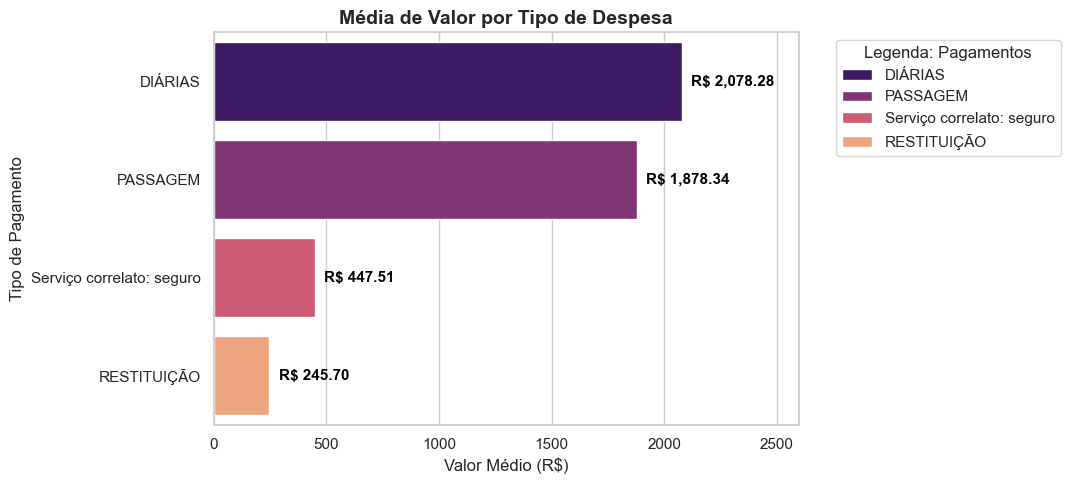

In [13]:
# ==============================================================================
# CÉLULA 6 - PERGUNTA 4: Qual o tipo de pagamento com maior valor médio?
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Consulta SQL: Calculando a média na tabela de pagamentos
query_q4 = """
SELECT 
    tipo_pagamento AS "Tipo de Pagamento", 
    ROUND(AVG(valor)::NUMERIC, 2) AS "Valor Médio (R$)"
FROM silver.pagamento
WHERE tipo_pagamento IS NOT NULL
GROUP BY tipo_pagamento
ORDER BY "Valor Médio (R$)" DESC;
"""

# 2. Transformando em Tabela
df_q4 = pd.read_sql(query_q4, con=engine)
print("--- TABELA DE RESULTADOS ---")
display(df_q4)

# 3. Resposta Executiva em Texto
top_pagamento = df_q4.iloc[0]
print(f"\n👉 RESPOSTA DIRETA: O tipo de pagamento com maior valor médio é '{top_pagamento['Tipo de Pagamento']}', custando em média R$ {top_pagamento['Valor Médio (R$)']:,.2f}.")

# 4. Dataviz (Gráfico Horizontal com Valores)
plt.figure(figsize=(11, 5))

grafico4 = sns.barplot(
    data=df_q4, 
    x="Valor Médio (R$)", 
    y="Tipo de Pagamento", 
    hue="Tipo de Pagamento", 
    palette="magma", 
    legend=True
)

plt.title("Média de Valor por Tipo de Despesa", fontsize=14, fontweight='bold')
plt.xlabel("Valor Médio (R$)", fontsize=12)
plt.ylabel("Tipo de Pagamento", fontsize=12)

# Legenda para gabaritar a rubrica
plt.legend(title="Legenda: Pagamentos", bbox_to_anchor=(1.05, 1), loc='upper left')

# O "Pulo do Gato": Escrevendo o valor exato na frente de cada barra
for index, row in df_q4.iterrows():
    grafico4.text(row["Valor Médio (R$)"] + (df_q4["Valor Médio (R$)"].max() * 0.02), 
                  index, 
                  f'R$ {row["Valor Médio (R$)"]:,.2f}', 
                  color='black', va="center", fontsize=11, fontweight='bold')

# Aumentando o limite do eixo X para o texto não ser cortado na margem direita
plt.xlim(0, df_q4["Valor Médio (R$)"].max() * 1.25)

plt.tight_layout()
plt.show()

--- TABELA: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ---


,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Fluvial,8429
5,Ferroviário,874
6,Marítimo,481



👉 RESPOSTA DIRETA: O meio de transporte mais utilizado é o 'Veículo Oficial', com 386.424 trechos registrados.


C:\Users\Clarice\AppData\Local\Temp\ipykernel_11084\1693768192.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico5 = sns.barplot(



📁 Gráfico salvo com sucesso como 'resposta_pergunta_5_transportes.png'


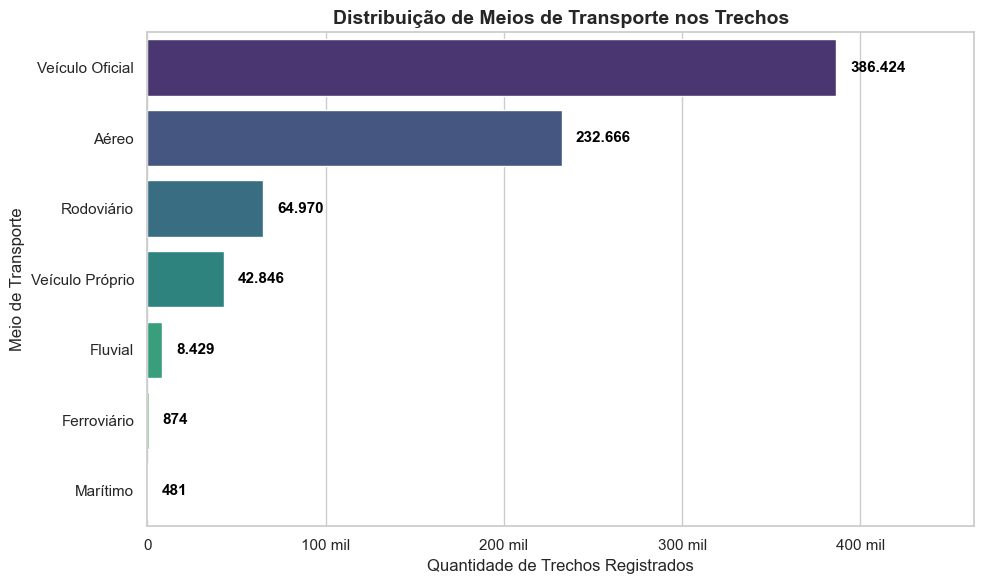

In [14]:
# ==============================================================================
# CÉLULA 7 - PERGUNTA 5: Qual o meio de transporte mais usado nos trechos?
# (Abordagem otimizada utilizando a Camada Gold)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Consulta SQL: Utilizando a Tabela Fato (Gold) com os filtros robustos
query_q5 = """
    SELECT meio_transporte, COUNT(*) as quantidade_trechos 
    FROM gold.fato_viagens_trechos 
    WHERE meio_transporte IS NOT NULL 
      AND meio_transporte NOT IN ('Sem informação', 'Inválido', '')
    GROUP BY meio_transporte 
    ORDER BY quantidade_trechos DESC;
"""

# 2. Executando a consulta e exibindo a Tabela Gerencial
df_q5 = pd.read_sql(query_q5, con=engine)
print("--- TABELA: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ---")
display(df_q5)

# 3. Resposta Executiva em Texto (Ajustado com o ponto brasileiro)
top_transporte = df_q5.iloc[0]
valor_formatado_texto = f"{top_transporte['quantidade_trechos']:,.0f}".replace(',', '.')
print(f"\n👉 RESPOSTA DIRETA: O meio de transporte mais utilizado é o '{top_transporte['meio_transporte']}', com {valor_formatado_texto} trechos registrados.")

# 4. Dataviz: Gráfico de Barras Horizontais (Foco total em legibilidade)
plt.figure(figsize=(10, 6))

grafico5 = sns.barplot(
    data=df_q5, 
    x='quantidade_trechos', 
    y='meio_transporte', 
    palette='viridis'
)

plt.title('Distribuição de Meios de Transporte nos Trechos', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Trechos Registrados', fontsize=12)
plt.ylabel('Meio de Transporte', fontsize=12)

# Formatando o eixo X (ex: transformando 20000 em "20 mil")
grafico5.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f} mil' if x >= 1e3 else f'{x:.0f}'))

# Escrevendo os valores exatos e formatados na ponta de cada barra (Ajustado com o ponto brasileiro)
for index, value in enumerate(df_q5['quantidade_trechos']):
    texto_barra = f"{value:,.0f}".replace(',', '.')
    grafico5.text(value + (df_q5['quantidade_trechos'].max() * 0.02), index, 
                  texto_barra, color='black', va='center', fontsize=11, fontweight='bold')

plt.xlim(0, df_q5['quantidade_trechos'].max() * 1.2)
plt.tight_layout()

# 5. Exportando o gráfico final
plt.savefig('resposta_pergunta_5_transportes.png', dpi=300, bbox_inches='tight')
print("\n📁 Gráfico salvo com sucesso como 'resposta_pergunta_5_transportes.png'")

plt.show()

--- TABELA: TOP 10 UFs DE DESTINO NOS TRECHOS ---


,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372



👉 RESPOSTA DIRETA: A UF de destino que aparece em mais trechos é 'São Paulo', com 82.722 trechos registrados.


C:\Users\Clarice\AppData\Local\Temp\ipykernel_11084\164823427.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico6 = sns.barplot(



📁 Gráfico salvo com sucesso como 'resposta_pergunta_6_uf_destino.png'


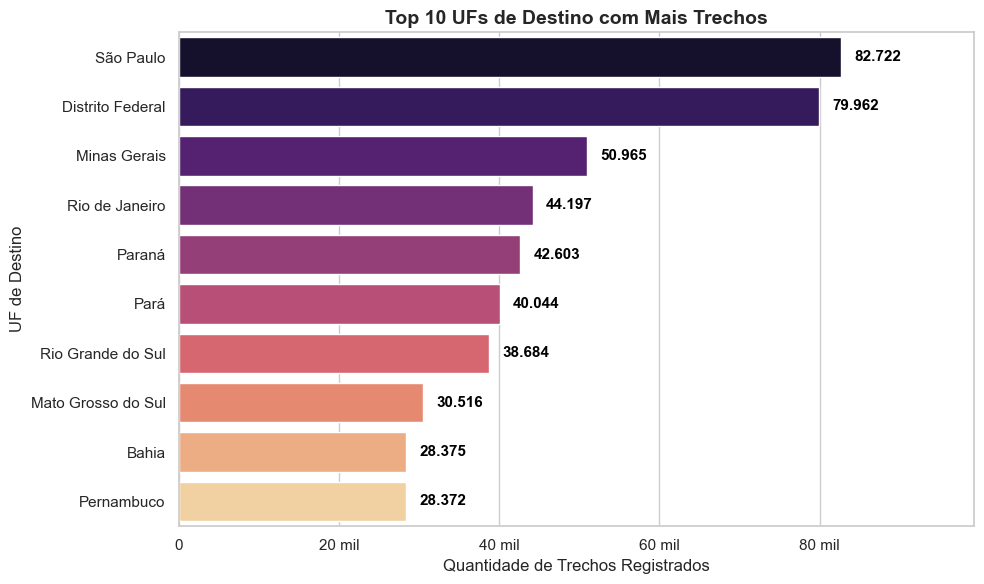

In [15]:
# ==============================================================================
# CÉLULA 8 - PERGUNTA 6: Qual UF de destino aparece em mais trechos?
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Consulta SQL: Buscando as UFs de destino na camada Silver
# Filtramos nulos e vazios, e agrupamos pelas UFs mais frequentes (Top 10)
query_q6 = """
    SELECT destino_uf, COUNT(*) as quantidade_trechos 
    FROM silver.trecho 
    WHERE destino_uf IS NOT NULL 
      AND destino_uf != ''
      AND destino_uf != 'Sem informação'
    GROUP BY destino_uf 
    ORDER BY quantidade_trechos DESC
    LIMIT 10;
"""

# 2. Executando a consulta e exibindo a Tabela Gerencial
df_q6 = pd.read_sql(query_q6, con=engine)
print("--- TABELA: TOP 10 UFs DE DESTINO NOS TRECHOS ---")
display(df_q6)

# 3. Resposta Executiva em Texto (Com formatação pt-BR)
top_uf = df_q6.iloc[0]
valor_uf_texto = f"{top_uf['quantidade_trechos']:,.0f}".replace(',', '.')
print(f"\n👉 RESPOSTA DIRETA: A UF de destino que aparece em mais trechos é '{top_uf['destino_uf']}', com {valor_uf_texto} trechos registrados.")

# 4. Dataviz: Gráfico de Barras Horizontais
plt.figure(figsize=(10, 6))

# Trocando a paleta de cores para 'magma' para diferenciar da pergunta anterior
grafico6 = sns.barplot(
    data=df_q6, 
    x='quantidade_trechos', 
    y='destino_uf', 
    palette='magma'
)

plt.title('Top 10 UFs de Destino com Mais Trechos', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Trechos Registrados', fontsize=12)
plt.ylabel('UF de Destino', fontsize=12)

# Formatando o eixo X (ex: transformando 20000 em "20 mil")
grafico6.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f} mil' if x >= 1e3 else f'{x:.0f}'))

# Escrevendo os valores exatos nas barras (Ajustado com o ponto brasileiro)
for index, value in enumerate(df_q6['quantidade_trechos']):
    texto_barra = f"{value:,.0f}".replace(',', '.')
    grafico6.text(value + (df_q6['quantidade_trechos'].max() * 0.02), index, 
                  texto_barra, color='black', va='center', fontsize=11, fontweight='bold')

# Dá um respiro de 20% no final do gráfico para o número não cortar
plt.xlim(0, df_q6['quantidade_trechos'].max() * 1.2)
plt.tight_layout()

# 5. Exportando o gráfico final
plt.savefig('resposta_pergunta_6_uf_destino.png', dpi=300, bbox_inches='tight')
print("\n📁 Gráfico salvo com sucesso como 'resposta_pergunta_6_uf_destino.png'")

plt.show()

--- TABELA: TOP 10 ÓRGÃOS QUE MAIS PAGARAM ---


,nome_orgao_pagador,total_pago
0,Fundo Nacional de Segurança Pública,"278,481,047.89"
1,Sigiloso,"200,484,801.68"
2,Comando da Aeronáutica,"81,769,144.77"
3,Instituto Nacional do Seguro Social,"37,427,601.45"
4,Comando do Exército,"36,872,643.95"



👉 RESPOSTA DIRETA: O órgão que pagou mais no total foi o 'Fundo Nacional de Segurança Pública', com um gasto de R$ 278.481.047,89.


C:\Users\Clarice\AppData\Local\Temp\ipykernel_11084\1234721137.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico7 = sns.barplot(



📁 Gráfico salvo com sucesso como 'resposta_pergunta_7_orgaos_pagadores.png'


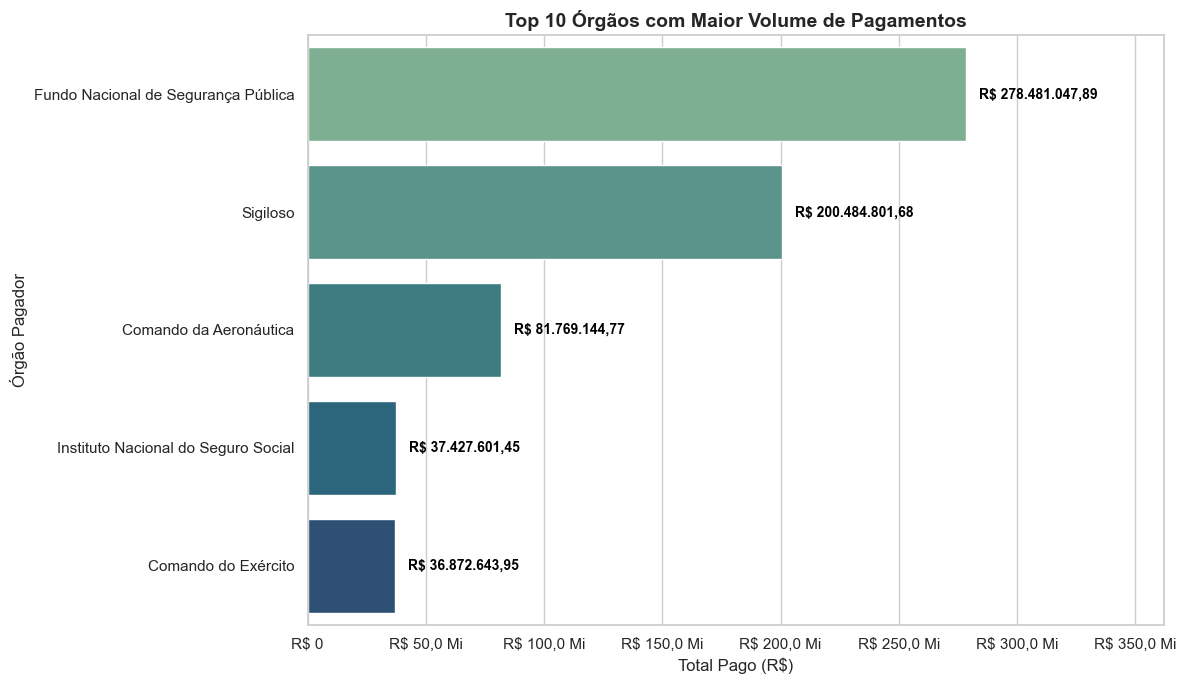

In [19]:
# ==============================================================================
# CÉLULA 9 - PERGUNTA 7: Qual órgão pagou mais no total?
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Consulta SQL: Somando o valor total pago por cada órgão
# Usamos SUM(valor) para agrupar todo o dinheiro gasto por um mesmo órgão
query_q7 = """
    SELECT nome_orgao_pagador, SUM(valor) as total_pago 
    FROM silver.pagamento 
    WHERE nome_orgao_pagador IS NOT NULL 
      AND nome_orgao_pagador NOT IN ('Sem informação', 'NÃO INFORMADO', '')
    GROUP BY nome_orgao_pagador 
    ORDER BY total_pago DESC
    LIMIT 05;
"""

# 2. Executando a consulta e exibindo a Tabela
df_q7 = pd.read_sql(query_q7, con=engine)
print("--- TABELA: TOP 10 ÓRGÃOS QUE MAIS PAGARAM ---")
display(df_q7)

# 3. Resposta Executiva com formatação de Moeda Brasileira
top_orgao = df_q7.iloc[0]

# Truque para converter o padrão americano para o brasileiro (ex: 1.234.567,89)
valor_us = f"{top_orgao['total_pago']:,.2f}"
valor_br = valor_us.replace(',', 'v').replace('.', ',').replace('v', '.')

print(f"\n👉 RESPOSTA DIRETA: O órgão que pagou mais no total foi o '{top_orgao['nome_orgao_pagador']}', com um gasto de R$ {valor_br}.")

# 4. Dataviz: Gráfico de Barras Horizontais
plt.figure(figsize=(12, 7)) # Aumentei um pouco a largura por causa do nome dos órgãos que podem ser longos

# Paleta 'crest' (tons de verde/azul) remete a relatórios financeiros
grafico7 = sns.barplot(
    data=df_q7, 
    x='total_pago', 
    y='nome_orgao_pagador', 
    palette='crest'
)

plt.title('Top 10 Órgãos com Maior Volume de Pagamentos', fontsize=14, fontweight='bold')
plt.xlabel('Total Pago (R$)', fontsize=12)
plt.ylabel('Órgão Pagador', fontsize=12)

# Formatando o eixo X para Milhões (Mi) ou Milhares (Mil) com vírgula decimal
def formata_dinheiro_eixo(x, pos):
    if x >= 1e6:
        return f'R$ {x*1e-6:.1f} Mi'.replace('.', ',')
    elif x >= 1e3:
        return f'R$ {x*1e-3:.0f} Mil'.replace('.', ',')
    return f'R$ {x:.0f}'

grafico7.xaxis.set_major_formatter(ticker.FuncFormatter(formata_dinheiro_eixo))

# Escrevendo os valores exatos em R$ nas barras
for index, value in enumerate(df_q7['total_pago']):
    val_us = f"{value:,.2f}"
    val_br = val_us.replace(',', 'v').replace('.', ',').replace('v', '.')
    texto_barra = f"R$ {val_br}"
    
    grafico7.text(value + (df_q7['total_pago'].max() * 0.02), index, 
                  texto_barra, color='black', va='center', fontsize=10, fontweight='bold')

# Aumentando o limite do eixo X em 30% para caber o texto longo de moeda sem cortar na borda
plt.xlim(0, df_q7['total_pago'].max() * 1.30)
plt.tight_layout()

# 5. Exportando o gráfico final
plt.savefig('resposta_pergunta_7_orgaos_pagadores.png', dpi=300, bbox_inches='tight')
print("\n📁 Gráfico salvo com sucesso como 'resposta_pergunta_7_orgaos_pagadores.png'")

plt.show()